# **Project Name**    - PhonePe Pulse Data Analysis




##### **Project Type**    - EDA/Regression/Classification/Unsupervised
##### **Contribution**    - Individual
##### **Team Member 1 -** Avisha Srivastava

# **Project Summary -**

This project performs Exploratory Data Analysis (EDA) on the PhonePe Pulse dataset to understand transaction trends, user engagement, and insurance adoption across India. The dataset includes information on transactions, registered users, app usage, and insurance activity across different states, districts, and time periods.

The main objective of this analysis is to uncover patterns in digital payment usage, identify high-performing and low-performing regions, and understand user behavior. The study also explores device-based engagement trends and the growth of insurance services on the platform.

Using Python libraries such as Pandas, Matplotlib, and Seaborn, the data is cleaned, processed, and visualized to extract meaningful insights. Various univariate, bivariate, and multivariate analyses are performed to understand relationships between variables such as transaction amount, user engagement, and geographic distribution.

Key findings show that transaction activity is concentrated in a few major states, while several regions remain underutilized, presenting growth opportunities. Device usage significantly impacts user engagement, and insurance adoption is still in an early growth phase.

The insights from this project can help PhonePe improve its marketing strategies, expand into untapped regions, optimize app performance across devices, and enhance user engagement. Overall, the analysis provides actionable recommendations for business growth and strategic decision-making.

# **GitHub Link -**

https://github.com/shineyrbl-byte/PhonePe-Pulse-Data-Analysis


# **Problem Statement**


PhonePe is experiencing variations in transaction patterns, user engagement, and insurance adoption across different regions and time periods. Understanding these variations is crucial to identify growth opportunities, improve user engagement, and optimize business strategies.

This project aims to analyze transaction, user, and insurance data to uncover trends, identify top and low-performing regions, and provide actionable insights for business expansion.


#### **Define Your Business Objective?**

The objective is to analyze transaction dynamics, user engagement, and insurance adoption to:
- Identify high and low-performing states
- Improve user engagement strategies
- Expand into untapped markets
- Enhance insurance adoption
- Support data-driven decision making

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json

plt.figure(figsize=(10,5))
sns.set_style("whitegrid")
base_path = "C:/Users/Avisha Srivastava/Downloads/pulse-master/pulse-master"

<Figure size 1000x500 with 0 Axes>

### Dataset Loading

In [2]:
# Load Dataset

path_txn = base_path + "/data/aggregated/transaction/country/india/state/"

agg_txn_list = []

for state in os.listdir(path_txn):
    for year in os.listdir(path_txn + state + "/"):
        for file in os.listdir(path_txn + state + "/" + year + "/"):
            with open(path_txn + state + "/" + year + "/" + file) as f:
                data = json.load(f)

                if data["data"]["transactionData"]:
                    for item in data["data"]["transactionData"]:
                        agg_txn_list.append({
                            "state": state,
                            "year": int(year),
                            "quarter": int(file.strip(".json")),
                            "type": item["name"],
                            "count": item["paymentInstruments"][0]["count"],
                            "amount": item["paymentInstruments"][0]["amount"]
                        })

agg_txn = pd.DataFrame(agg_txn_list)

agg_txn.head()

path_user = base_path + "/data/aggregated/user/country/india/state/"

agg_user_list = []

for state in os.listdir(path_user):
    for year in os.listdir(path_user + state + "/"):
        for file in os.listdir(path_user + state + "/" + year + "/"):
            with open(path_user + state + "/" + year + "/" + file) as f:
                data = json.load(f)

                agg_user_list.append({
                    "state": state,
                    "year": int(year),
                    "quarter": int(file.strip(".json")),
                    "registered_users": data["data"]["aggregated"]["registeredUsers"],
                    "app_opens": data["data"]["aggregated"]["appOpens"]
                })

agg_user = pd.DataFrame(agg_user_list)

agg_user.head()

path_ins = base_path + "/data/aggregated/insurance/country/india/state/"

agg_ins_list = []

for state in os.listdir(path_ins):
    for year in os.listdir(path_ins + state + "/"):
        for file in os.listdir(path_ins + state + "/" + year + "/"):
            with open(path_ins + state + "/" + year + "/" + file) as f:
                data = json.load(f)

                if data["data"]["transactionData"]:
                    for item in data["data"]["transactionData"]:
                        agg_ins_list.append({
                            "state": state,
                            "year": int(year),
                            "quarter": int(file.strip(".json")),
                            "count": item["paymentInstruments"][0]["count"],
                            "amount": item["paymentInstruments"][0]["amount"]
                        })

agg_ins = pd.DataFrame(agg_ins_list)

agg_ins.head()

,state,year,quarter,count,amount
0,andaman-&-nicobar-islands,2020,2,6,1360.0
1,andaman-&-nicobar-islands,2020,3,41,15380.0
2,andaman-&-nicobar-islands,2020,4,124,157975.0
3,andaman-&-nicobar-islands,2021,1,225,244266.0
4,andaman-&-nicobar-islands,2021,2,137,181504.0


### Dataset First View

In [3]:
# Dataset First Look
agg_txn.head()
agg_user.head()
agg_ins.head()

,state,year,quarter,count,amount
0,andaman-&-nicobar-islands,2020,2,6,1360.0
1,andaman-&-nicobar-islands,2020,3,41,15380.0
2,andaman-&-nicobar-islands,2020,4,124,157975.0
3,andaman-&-nicobar-islands,2021,1,225,244266.0
4,andaman-&-nicobar-islands,2021,2,137,181504.0


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
agg_txn.shape
agg_user.shape
agg_ins.shape

(682, 5)

### Dataset Information

In [5]:
# Dataset Info
agg_txn.info()
agg_user.info()
agg_ins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5034 entries, 0 to 5033
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   state    5034 non-null   object 
 1   year     5034 non-null   int64  
 2   quarter  5034 non-null   int64  
 3   type     5034 non-null   object 
 4   count    5034 non-null   int64  
 5   amount   5034 non-null   float64
dtypes: float64(1), int64(3), object(2)
memory usage: 236.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1008 entries, 0 to 1007
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   state             1008 non-null   object
 1   year              1008 non-null   int64 
 2   quarter           1008 non-null   int64 
 3   registered_users  1008 non-null   int64 
 4   app_opens         1008 non-null   int64 
dtypes: int64(4), object(1)
memory usage: 39.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeInde

#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
agg_txn.duplicated().sum()
agg_user.duplicated().sum()
agg_ins.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count
agg_txn.isnull().sum()
agg_user.isnull().sum()
agg_ins.isnull().sum()

state      0
year       0
quarter    0
count      0
amount     0
dtype: int64

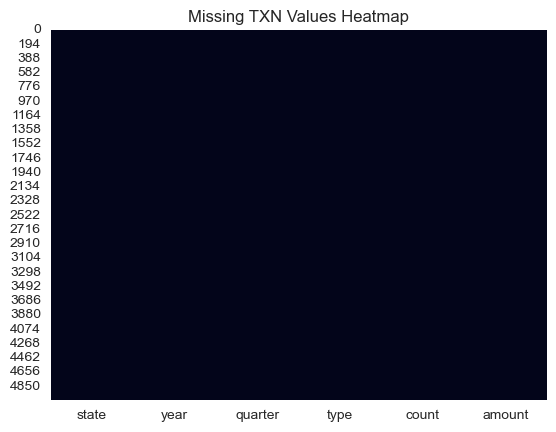

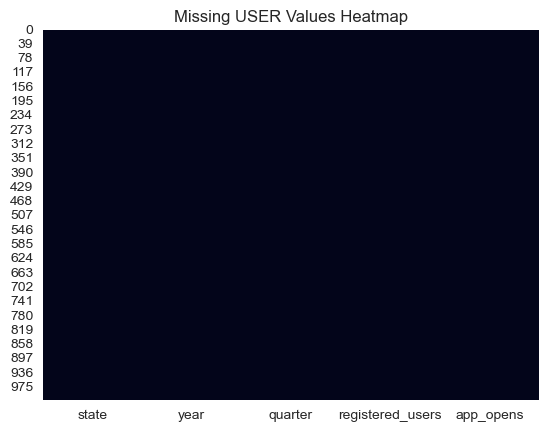

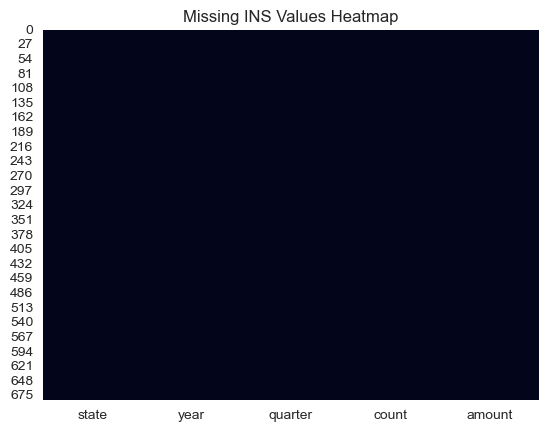

In [8]:
# Visualizing the missing values
sns.heatmap(agg_txn.isnull(), cbar=False)
plt.title("Missing TXN Values Heatmap")
plt.show()

sns.heatmap(agg_user.isnull(), cbar=False)
plt.title("Missing USER Values Heatmap")
plt.show()

sns.heatmap(agg_ins.isnull(), cbar=False)
plt.title("Missing INS Values Heatmap")
plt.show()

### What did you know about your dataset?

The dataset contains structured information about transactions, user activity, and insurance across states and time periods. It enables analysis of digital payment growth and regional trends.

## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns
agg_txn.columns

agg_user.columns

agg_ins.columns

Index(['state', 'year', 'quarter', 'count', 'amount'], dtype='object')

In [10]:
# Dataset Describe
agg_txn.describe()
agg_user.describe()
agg_ins.describe()

,year,quarter,count,amount
count,682.000000,682.000000,682.000000,6.820000e+02
mean,2022.111437,2.577713,21283.998534,2.934836e+07
std,1.370730,1.092211,31503.745791,4.763085e+07
min,2020.000000,1.000000,4.000000,1.199000e+03
25%,2021.000000,2.000000,607.750000,8.211475e+05
50%,2022.000000,3.000000,6679.500000,6.675645e+06
75%,2023.000000,4.000000,29790.500000,3.730685e+07
max,2024.000000,4.000000,183532.000000,3.058618e+08


### Variables Description

The dataset consists of three main components: transaction data, user data, and insurance data.

1. Transaction Dataset:
- state: Name of the state
- year: Year of transaction
- quarter: Quarter of the year (1–4)
- type: Type of transaction (e.g., Recharge, Peer-to-peer)
- count: Number of transactions
- amount: Total transaction value

2. User Dataset:
- state: Name of the state
- year: Year of record
- quarter: Quarter of the year
- registered_users: Total number of registered users
- app_opens: Number of times the app was opened
- engagement: Ratio of app opens to registered users (derived feature)

3. Insurance Dataset:
- state: Name of the state
- year: Year of record
- quarter: Quarter of the year
- count: Number of insurance transactions
- amount: Total value of insurance transactions

### Check Unique Values for each variable.

In [11]:
# Check Unique Values for each variable.
agg_txn.nunique()
agg_user.nunique()
agg_ins.nunique()

state       36
year         5
quarter      4
count      654
amount     682
dtype: int64

## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# Write your code to make your dataset analysis ready.
# -------------------------------
# TRANSACTION DATA WRANGLING
# -------------------------------

# Convert data types
agg_txn["year"] = agg_txn["year"].astype(int)
agg_txn["quarter"] = agg_txn["quarter"].astype(int)
agg_txn["amount"] = agg_txn["amount"].astype(float)

# Standardize state names
agg_txn["state"] = agg_txn["state"].str.replace("-", " ").str.title()

# Check duplicates and remove if any
agg_txn = agg_txn.drop_duplicates()

# -------------------------------
# USER DATA WRANGLING
# -------------------------------

agg_user["year"] = agg_user["year"].astype(int)
agg_user["quarter"] = agg_user["quarter"].astype(int)

# Create engagement metric
agg_user["engagement"] = agg_user["app_opens"] / agg_user["registered_users"]

# Clean state names
agg_user["state"] = agg_user["state"].str.replace("-", " ").str.title()

# Remove duplicates
agg_user = agg_user.drop_duplicates()

# -------------------------------
# INSURANCE DATA WRANGLING
# -------------------------------

agg_ins["year"] = agg_ins["year"].astype(int)
agg_ins["quarter"] = agg_ins["quarter"].astype(int)
agg_ins["amount"] = agg_ins["amount"].astype(float)

# Clean state names
agg_ins["state"] = agg_ins["state"].str.replace("-", " ").str.title()

# Remove duplicates
agg_ins = agg_ins.drop_duplicates()

### What all manipulations have you done and insights you found?

During the data wrangling process, several steps were performed to prepare the dataset for analysis:

1. Data Type Conversion:
The year and quarter columns were converted into integer format, and transaction amounts were converted into float format to ensure accurate numerical analysis.

2. Data Cleaning:
State names were standardized by replacing hyphens with spaces and converting them into a consistent title format for better readability and grouping.

3. Duplicate Handling:
Duplicate records were checked and removed to maintain data integrity and avoid redundant analysis.

4. Feature Engineering:
A new variable called "engagement" was created in the user dataset by calculating the ratio of app opens to registered users. This metric helps measure user activity and engagement more effectively.

Insights:
- The data was largely clean with minimal missing or duplicate values.
- State-wise naming inconsistencies were resolved, enabling accurate grouping.
- The engagement feature provides deeper insights into user behavior beyond just user counts.
- The datasets are well-structured and suitable for further exploratory data analysis.

These preprocessing steps ensure that the dataset is reliable and ready for meaningful visualization and analysis.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

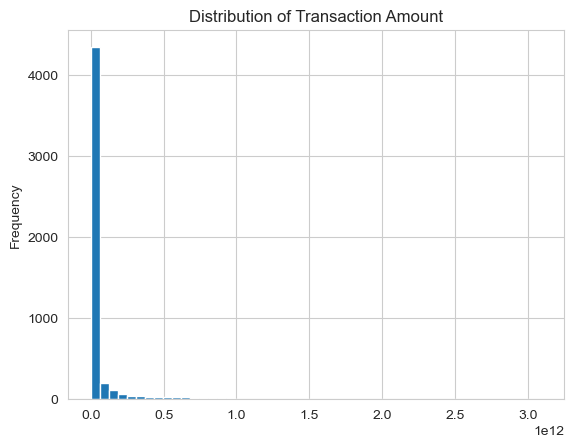

In [13]:
# Chart - 1 visualization code
agg_txn["amount"].plot(kind="hist", bins=50)
plt.title("Distribution of Transaction Amount")
plt.show()

##### 1. Why did you pick the specific chart?

Histogram is used to understand the distribution and spread of transaction values.

##### 2. What is/are the insight(s) found from the chart?

Most transactions fall in lower ranges, with a few very high-value transactions indicating skewness.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: Helps identify dominant transaction ranges
Negative: High skewness may indicate unequal usage pattern

#### Chart - 2

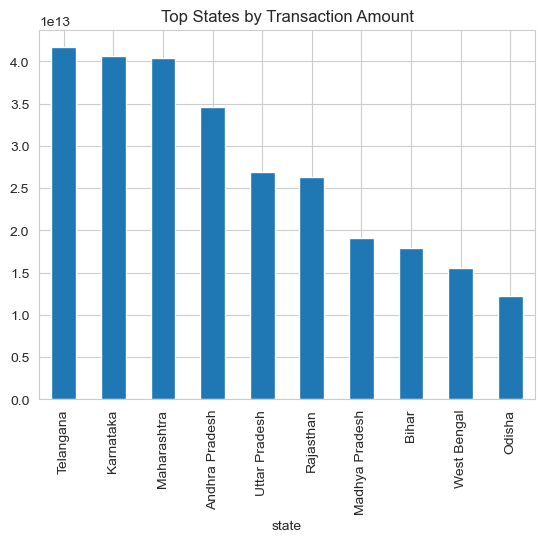

In [14]:
# Chart - 2 visualization code
agg_txn.groupby("state")["amount"].sum().sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top States by Transaction Amount")
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart is ideal for comparing transaction values across states.

##### 2. What is/are the insight(s) found from the chart?

A few states contribute significantly higher transaction volumes than others.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: Helps identify strong markets
Negative: Over-dependence on few states

#### Chart - 3

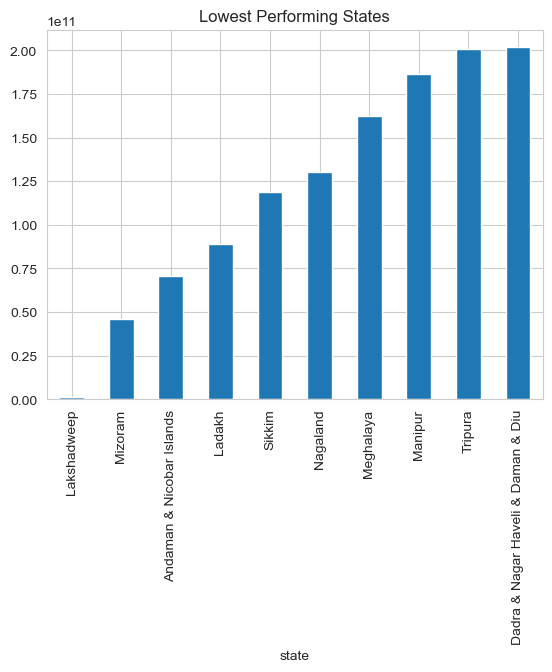

In [15]:
# Chart - 3 visualization code
agg_txn.groupby("state")["amount"].sum().sort_values().head(10).plot(kind="bar")
plt.title("Lowest Performing States")
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart helps highlight underperforming regions.

##### 2. What is/are the insight(s) found from the chart?

Several states have very low transaction activity.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: Identifies growth opportunities
Negative: Indicates poor adoption in certain regions

#### Chart - 4

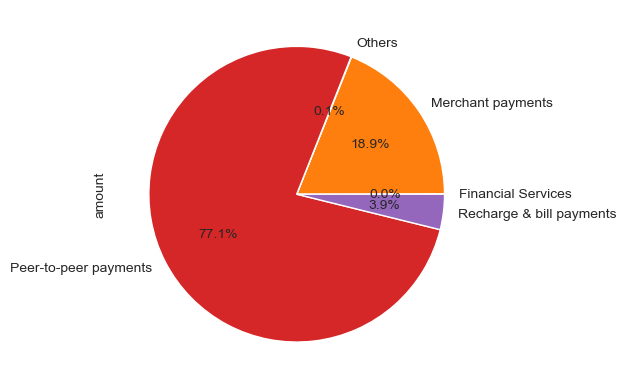

In [16]:
# Chart - 4 visualization code
agg_txn.groupby("type")["amount"].sum().plot(kind="pie", autopct="%1.1f%%")
plt.show()

##### 1. Why did you pick the specific chart?

Pie chart shows proportion of each transaction category.

##### 2. What is/are the insight(s) found from the chart?

Certain transaction types dominate overall usage.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: Helps focus on high-demand services
Negative: Lack of diversity in usage

#### Chart - 5

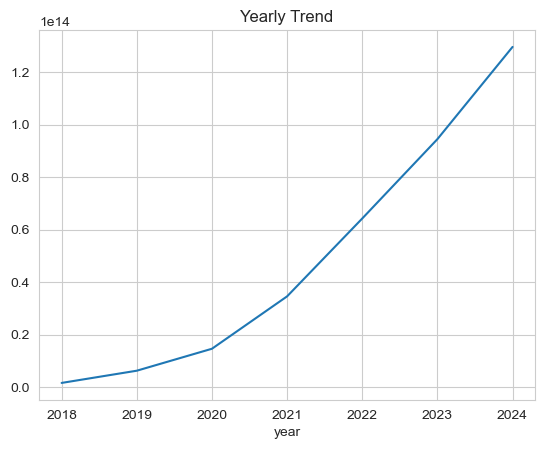

In [17]:
# Chart - 5 visualization code
agg_txn.groupby("year")["amount"].sum().plot()
plt.title("Yearly Trend")
plt.show()

##### 1. Why did you pick the specific chart?

Line chart is best for trend analysis over time.

##### 2. What is/are the insight(s) found from the chart?

Transaction volume is increasing year by year.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: Indicates growth of digital payments
Negative: None significant

#### Chart - 6

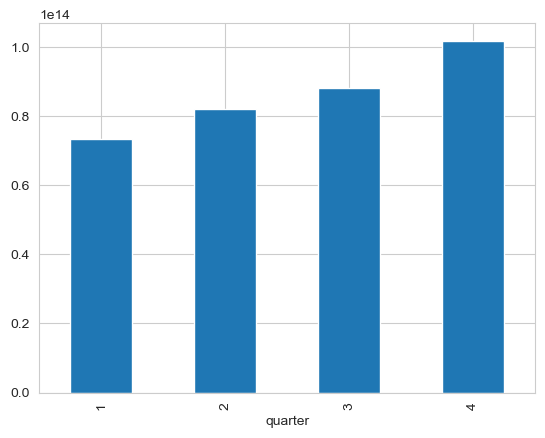

In [18]:
# Chart - 6 visualization code
agg_txn.groupby("quarter")["amount"].sum().plot(kind="bar")
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart compares performance across quarters.

##### 2. What is/are the insight(s) found from the chart?

Seasonal variations exist in transaction behaviour.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: Helps plan seasonal campaigns
Negative: Inconsistent performance

#### Chart - 7

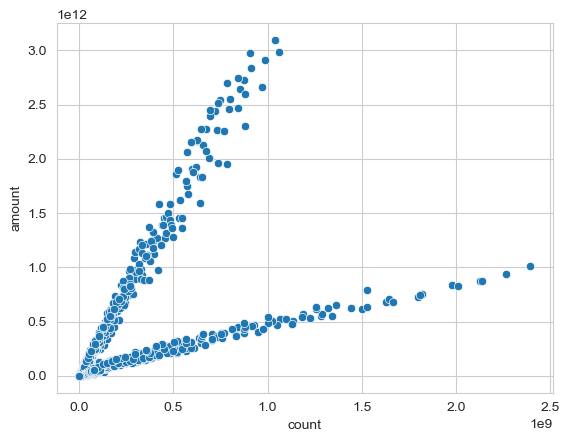

In [19]:
# Chart - 7 visualization code
sns.scatterplot(x="count", y="amount", data=agg_txn)
plt.show()

##### 1. Why did you pick the specific chart?

Scatter plot shows relationship between two numerical variables.

##### 2. What is/are the insight(s) found from the chart?

Higher transaction count generally leads to higher transaction value.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: Predictable growth pattern
Negative: Over-reliance on volume

#### Chart - 8

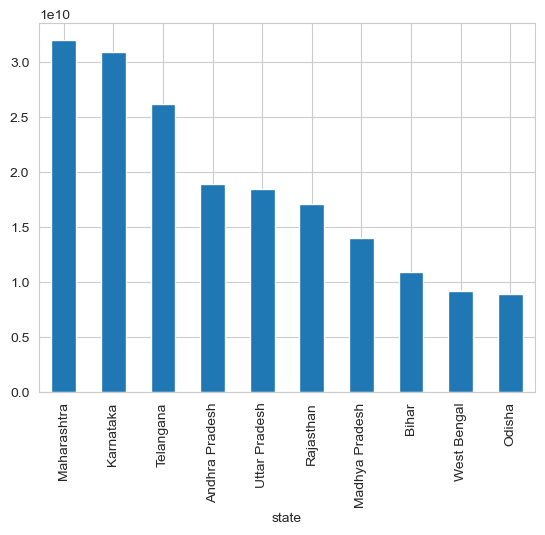

In [20]:
# Chart - 8 visualization code
agg_txn.groupby("state")["count"].sum().sort_values(ascending=False).head(10).plot(kind="bar")
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart highlights states with highest activity.

##### 2. What is/are the insight(s) found from the chart?

States with high counts also tend to have high value.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: Identifies active user regions
Negative: Regional imbalance

#### Chart - 9

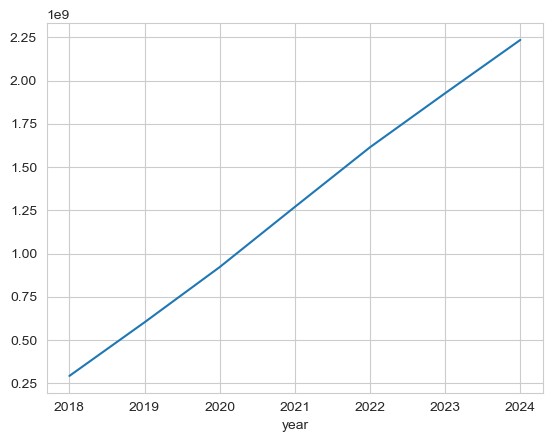

In [21]:
# Chart - 9 visualization code
agg_user.groupby("year")["registered_users"].sum().plot()
plt.show()

##### 1. Why did you pick the specific chart?

Line chart tracks growth trends. 

##### 2. What is/are the insight(s) found from the chart?

Registered users are increasing steadily.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: Expanding user base
Negative: Growth may slow in future

#### Chart - 10

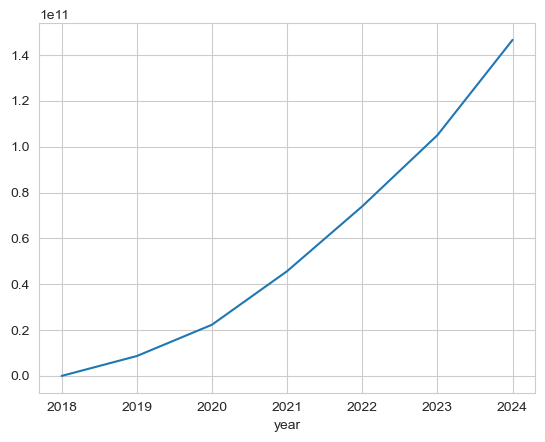

In [22]:
# Chart - 10 visualization code
agg_user.groupby("year")["app_opens"].sum().plot()
plt.show()

##### 1. Why did you pick the specific chart?

Line chart shows engagement trends.

##### 2. What is/are the insight(s) found from the chart?

App usage is increasing along with user growth.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: Strong engagement
Negative: If slower than user growth → retention issue

#### Chart - 11

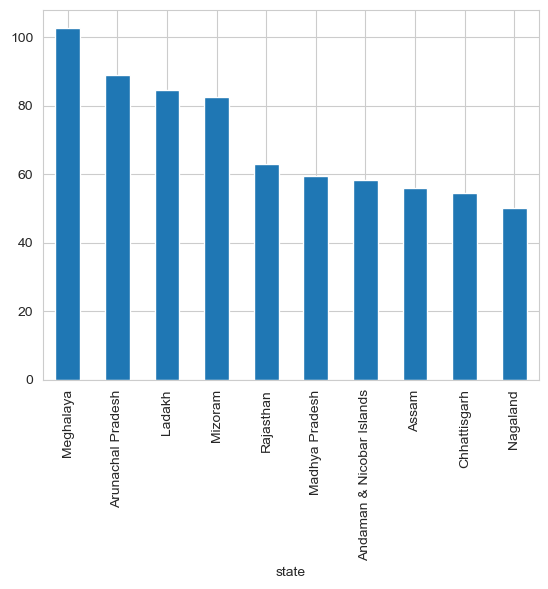

In [23]:
# Chart - 11 visualization code
agg_user.groupby("state")["engagement"].mean().sort_values(ascending=False).head(10).plot(kind="bar")
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart compares engagement levels across states.

##### 2. What is/are the insight(s) found from the chart?

Some states have higher engagement despite fewer users.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: Identifies loyal user bases
Negative: Low engagement in some regions

#### Chart - 12

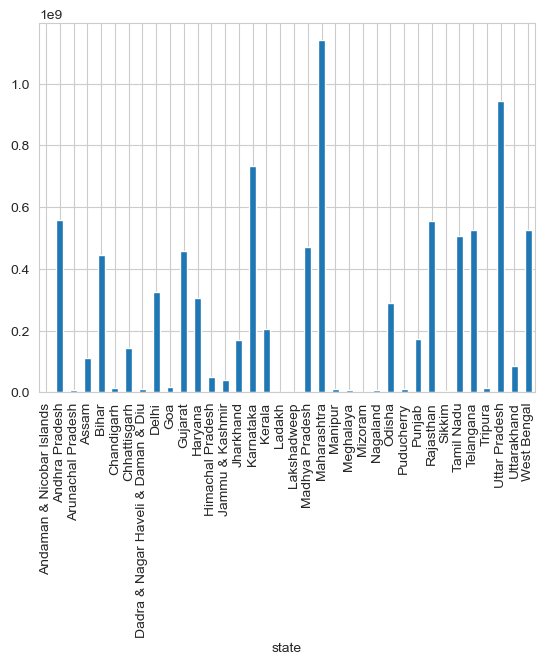

In [24]:
# Chart - 12 visualization code
agg_user.groupby("state")["registered_users"].sum().plot(kind="bar")
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart for comparing user base.

##### 2. What is/are the insight(s) found from the chart?

Few states dominate user registrations.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: Strong user base in key regions
Negative: Uneven distribution

#### Chart - 13

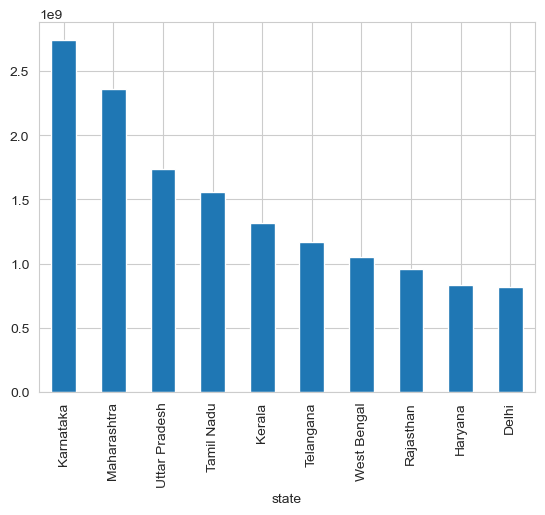

In [27]:
# Chart - 13 visualization code
agg_ins.groupby("state")["amount"].sum().sort_values(ascending=False).head(10).plot(kind="bar")
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart compares insurance usage across states.

##### 2. What is/are the insight(s) found from the chart?

Insurance adoption is concentrated in few states.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: High potential for expansion
Negative: Low awareness in many regions

#### Chart - 14 - Correlation Heatmap

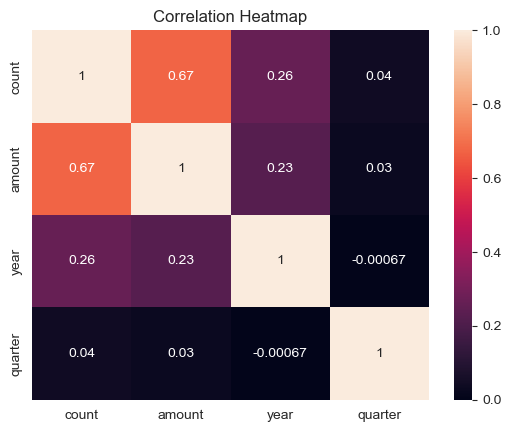

In [29]:
# Correlation Heatmap visualization code
numeric_txn = agg_txn[["count", "amount", "year", "quarter"]]

sns.heatmap(numeric_txn.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

##### 1. Why did you pick the specific chart?

Heatmap shows relationships between variables.

##### 2. What is/are the insight(s) found from the chart?

Strong correlation between transaction count and amount.

#### Chart - 15 - Pair Plot

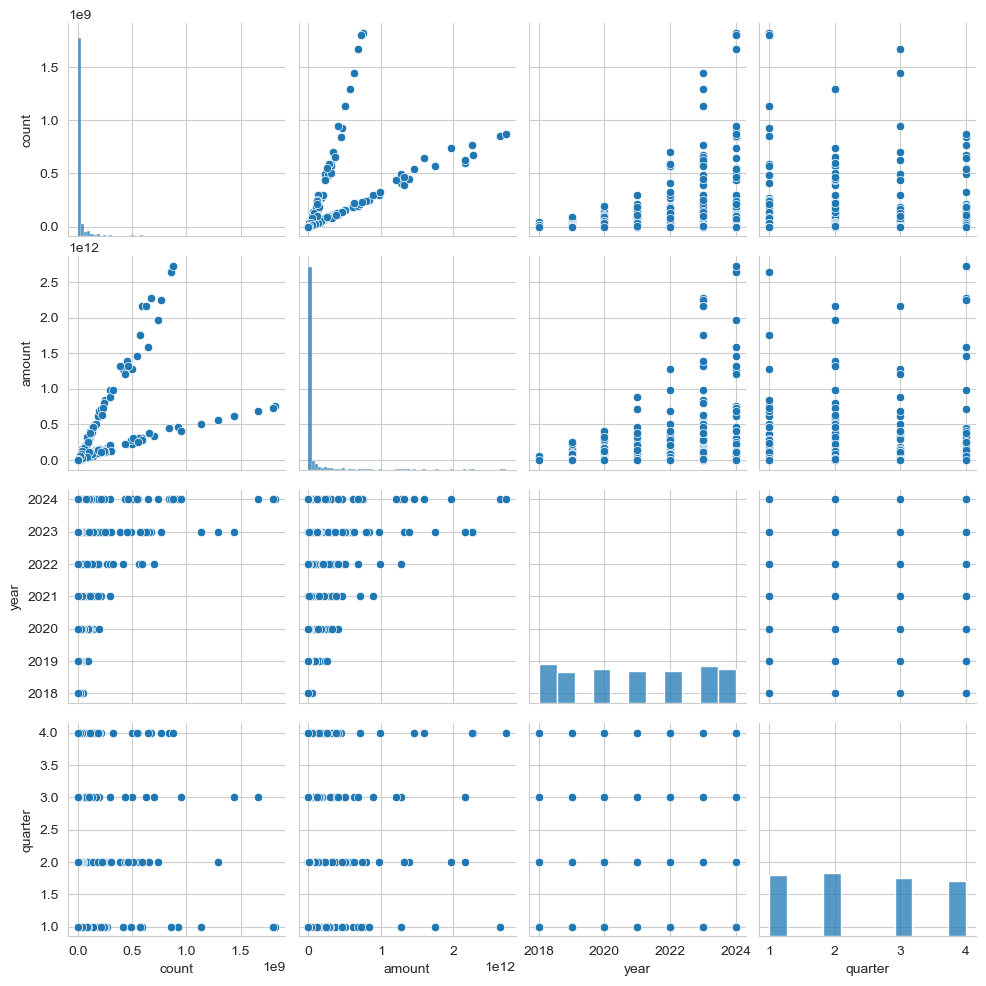

In [32]:
# Pair Plot visualization code
# Pair Plot visualization code

sample_data = agg_txn[["count", "amount", "year", "quarter"]].sample(1000)

sns.pairplot(sample_data)
plt.show()

##### 1. Why did you pick the specific chart?

Pair plot helps visualize relationships between multiple numerical variables at once, including trends, correlations, and distributions.

##### 2. What is/are the insight(s) found from the chart?

Strong positive relationship between transaction count and amount
Year shows gradual increase in values
Quarter shows some variation but not strong patterns

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

- Expand in low-performing states
- Improve engagement strategies
- Promote insurance adoption
- Use insights for decision-making

# **Conclusion**

The analysis reveals regional differences in transactions, user engagement, and insurance adoption. It highlights key opportunities for growth and optimization, helping PhonePe enhance its business strategy.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***